# Sampling a Data Stream 

---

### Data streams 

- A list of ordered or timestamped **data objects, or "events"**

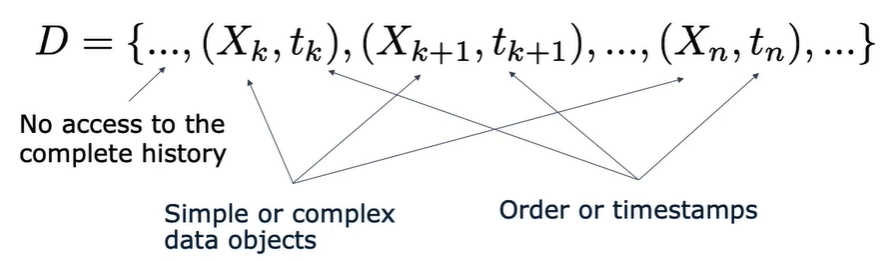

### Example: the tweet stream 

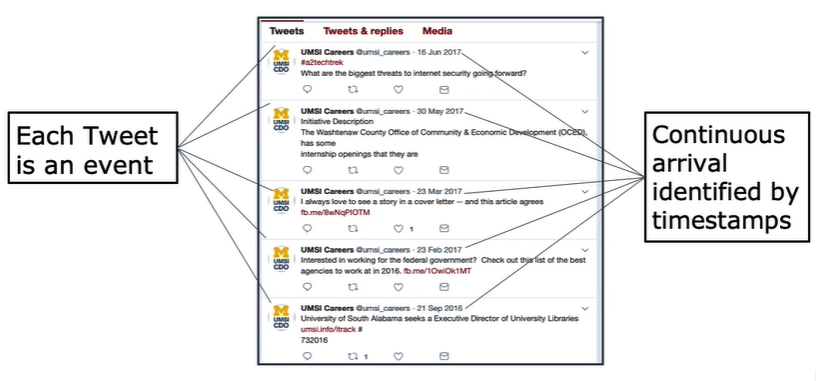

### Challenges of mining stream data 

- One example question that summarizes all the challenges: 
    - 500 million tweets being generated per day 
    - you have the capacity to keep 1000 tweets (at a given time)
    - How do you do data mining? 

### Objective of mining stream data 

- Store only a small portion of data 
- update online 
- deal with events in order 
- Do not look back 

### Sampling 

- Most of these challenges can be addressed if we always have a sample of the events in hands
- Apply the data mining funcitonalities on the sample
- An unbiased, random sample is preferred 
- But how to sample a stream?

### Sampling a data stream 

- How to randomly sample K events from a data stream so that: 
    - the sample adapts to incoming events?
    - every event (historical and incoming) has the same chance to be included in the sample?

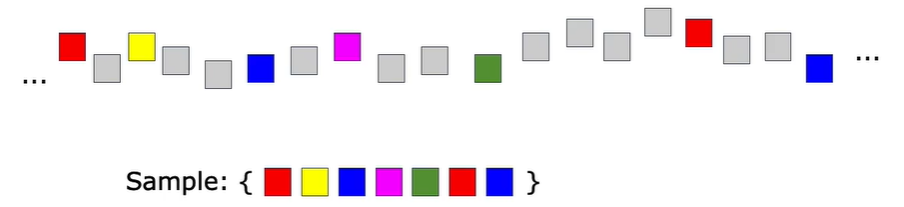

### If it isn't a stream 

- suppose there are N static events in total 
- sample k events uniformly at random without replacement 
- every event has a probability of K/N to be included 

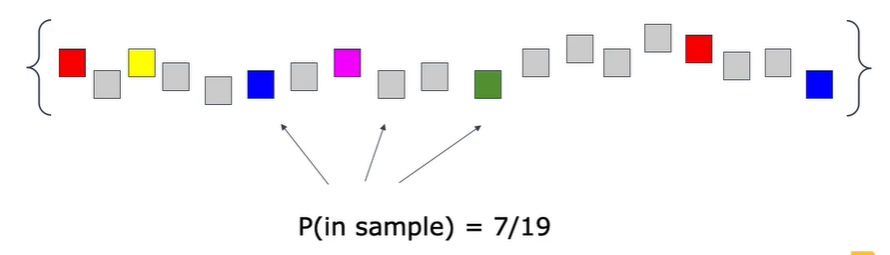

#### First attempt 

- for every incoming event, throw a coin to decide whether it should be included in the sample or not 
- assign a small enough probability (ideally K/N) to the process 
- but we don't know N, so try some big number 

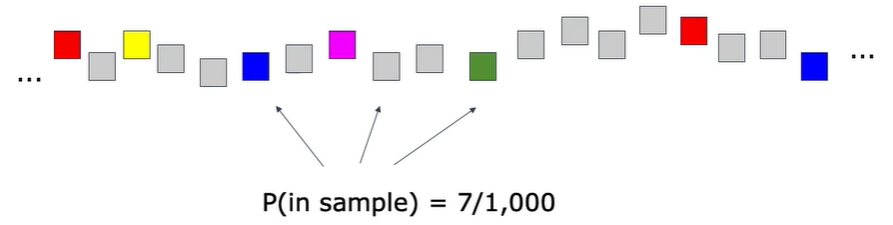

##### Pros and Cons 

- pros: as easy as randomly sampling a static set 
- cons: if the stream is small, then we won't have enough samples; if the stream is large, then we'll eventually run out of capacity despite the small probability. 

#### Second attempt 

- always keep the most recent K events 
- when a new event comes in , kcik out the oldest one 

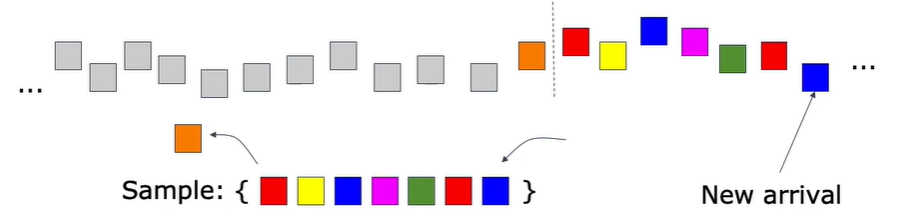

##### Pros and Cons

- pros: always have a sample of K, never run out of capacity 
- cons: sample contains only recent events; old events are all kicked out when N > K 
- Concept drift 



#### Combining 1 and 2

- sample one event from every chunk of M, then keep the most recent K samples.

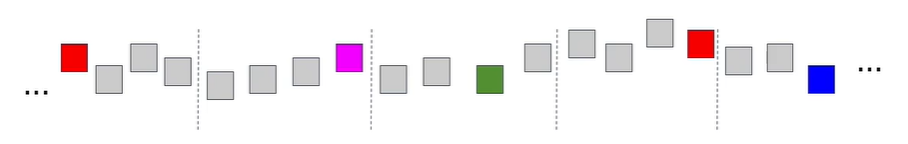

##### Pros and Cons 

- pros: every recent event has a probability of 1/M to be included into the sample (ideally, M ~ N/K)
- pros: never run out of capacity 
- cons: concept drift is still possible 
- cons: not fair for older events, as they are more likely to be kicked out 

#### More attempts 

- new event: include it into the sample with a probability of K/N 
- N equals the number of total events so far (or an estimated total number of events)

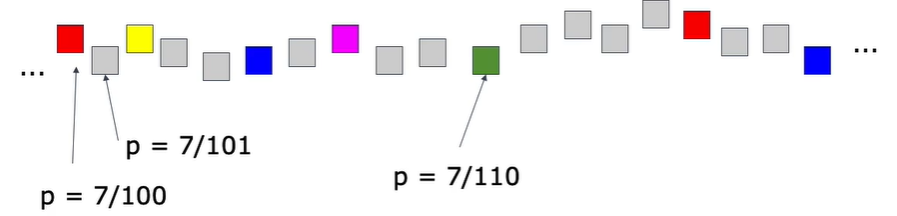

- problem: N increases over time! (and estimation can be wrong)
- Unfair to newer events 

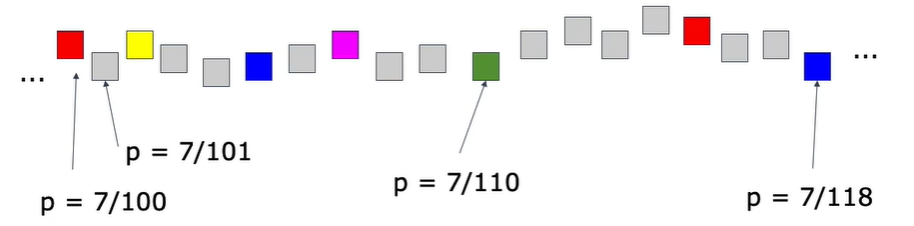

#### If only... 

- when the N-th event has arrived, every event (including the oldest event) has exactly a probability of K/N to be sampled
- we know N (no need to estimate)
- for new event, flip a coin with p = K/N to include it or discard it 
- How do we change the sampling probability of an older event? 

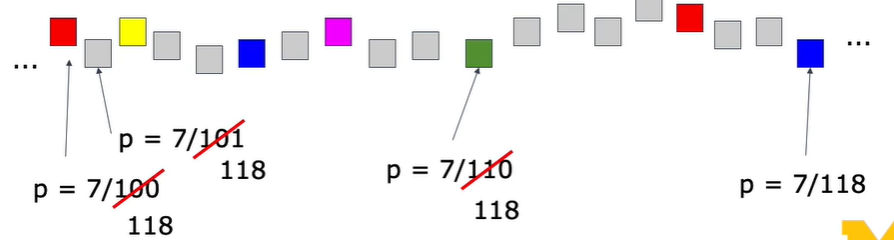

### Challenges of updating 

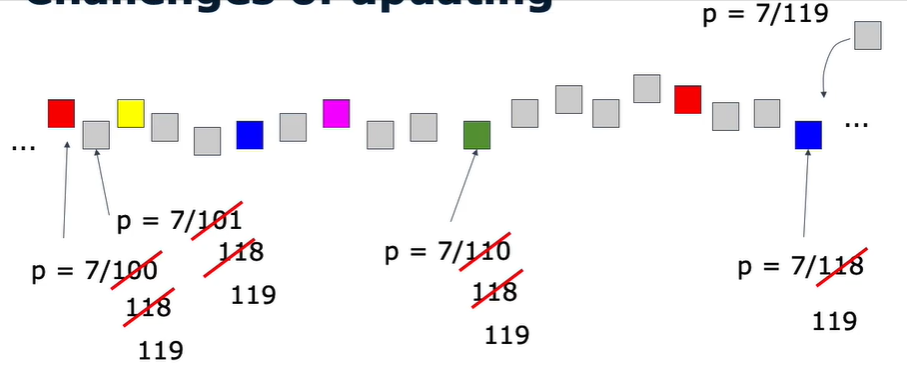

### The key 

- adjusting probability with resampling 
- probability of a new event in sample: K/N 
- probability of an older event in sample: > K/N 
    - Needs to be reduced 
- Solution: flip the coin again to randomly kick out an old event 